# Train/test split, panel construction and feature engineering

Two panels get built here:
1. **Severity panel** - one row per claim, used to train the repair-cost regression model. It now includes features of the garage that actually did the work, so the model can predict a garage-conditional cost (needed for the final ranking - without garage features the predicted cost would be identical across all 100 candidates and the ranking would collapse to probability only).
2. **Choice panel** - one row per (claim, candidate garage), used to train the garage-selection model. Built by expanding every claim against its manufacturer's 100 candidate garages, with the actually-chosen garage labeled `1` and the rest `0`.

Both panels share the same claim-level train/test split so the two models are evaluated consistently and can be combined later without any train/test mixing.

## Imports and loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

from src.features import haversine_km, add_interaction_features

SEED = 42

claims = pd.read_csv("data/claims_clean.csv", parse_dates=["event_date", "open_date"])
garages = pd.read_csv("data/garages.csv")
potential = pd.read_csv("data/potential_garages_by_manufacturer.csv")

print(f"claims:    {claims.shape}")
print(f"garages:   {garages.shape}")
print(f"potential: {potential.shape}")

claims:    (2000, 25)
garages:   (150, 8)
potential: (2500, 2)


## Train / test split

Splitting **chronologically** by `event_date` (80/20): train on the earliest claims, test on the most recent ones. This matches how the model will actually be used in production - always predicting on claims that happened after the ones it was trained on - and avoids a random split silently giving the model a look at "future" patterns during training.

**Why no fixed validation set:** with 2,000 claims, a 15% validation slice is ~300 claims and tuning on it is noisy. Instead, hyperparameter tuning in the next step uses cross validation inside the train split, and the test set is touched exactly once at the end. The same claim-level split is reused for both panels, so no claim's rows leak across train/test in the choice panel either.

In [2]:
claims = claims.sort_values("event_date").reset_index(drop=True)

n = len(claims)
train_end = int(n * 0.80)

claims["split"] = "train"
claims.loc[train_end:, "split"] = "test"

print(claims["split"].value_counts())
print()
print(claims.groupby("split")["event_date"].agg(["min", "max"]))

split
train    1600
test      400
Name: count, dtype: int64

             min        max
split                      
test  2025-08-04 2025-12-15
train 2024-01-01 2025-08-04


**Representation check.** A chronological split only works if it doesn't accidentally starve train or test of some category (e.g. one manufacturer only showing up late in the timeline). Checking the key categorical variables across splits before moving on.

In [3]:
check_cols = ["car_manufacturer", "damage_type", "insured_city_type", "insured_city_ses_cluster", "opened_by"]

for col in check_cols:
    print(f"--- {col} ---")
    print(pd.crosstab(claims[col], claims["split"], normalize="columns").round(3))
    print()

--- car_manufacturer ---
split              test  train
car_manufacturer              
Audi              0.055  0.046
BMW               0.042  0.037
Chery             0.042  0.036
Chevrolet         0.038  0.038
Citroen           0.045  0.044
Ford              0.025  0.044
Geely             0.050  0.032
Honda             0.045  0.043
Hyundai           0.060  0.043
Kia               0.045  0.045
Mazda             0.050  0.038
Mercedes          0.042  0.038
Mitsubishi        0.042  0.035
Nissan            0.038  0.036
Opel              0.030  0.035
Peugeot           0.025  0.041
Renault           0.028  0.047
Seat              0.048  0.040
Skoda             0.045  0.034
Subaru            0.020  0.046
Suzuki            0.042  0.041
Tesla             0.025  0.042
Toyota            0.050  0.041
Volkswagen        0.035  0.036
Volvo             0.032  0.042

--- damage_type ---
split         test  train
damage_type              
collision    0.480  0.501
fire         0.028  0.028
glass        

Distributions look consistent across splits for every variable - no manufacturer, damage type, or locality segment is meaningfully over/under-represented in either split. The synthetic data has no real seasonal or trend signal, so the chronological cut doesn't cost us anything in representation while giving a more realistic (out-of-time) evaluation setup. This also justifies using plain shuffled KFold for tuning inside train in the next step.

## Severity panel

The severity model needs claim-level features plus features of the garage that did the repair. The garage side matters because the final deliverable ranks garages by choice probability AND expected cost - so cost has to be able to differ between garages of the same claim. In training, the garage features come from the garage actually chosen; at ranking time, they'll come from each candidate garage in turn.

**Limitation worth stating:** we only observe costs at garages that were actually chosen, so cross-garage cost predictions carry some selection bias. Flagged as a known limitation, with causal correction methods as a next step.

In [4]:
severity_panel = claims.merge(
    garages[["garage_id", "garage_city_type", "garage_city_ses_cluster", "garage_lat", "garage_lon"]],
    left_on="chosen_garage_id", right_on="garage_id", how="left",
)

# distance from the insured to the garage that did the work
severity_panel["dist_km"] = haversine_km(
    severity_panel["insured_lat"], severity_panel["insured_lon"],
    severity_panel["garage_lat"], severity_panel["garage_lon"],
)

severity_features = [
    "vehicle_age", "vehicle_value_nis", "driver_age", "damage_type",
    "car_manufacturer", "insured_city_type", "insured_city_ses_cluster",
    "opened_by", "driver_age_was_imputed",
    "garage_city_type", "garage_city_ses_cluster", "dist_km",
]

severity_panel = severity_panel[["claim_id", "split", "damage_cost_nis"] + severity_features].copy()
severity_panel["log_damage_cost"] = np.log1p(severity_panel["damage_cost_nis"])

print(severity_panel.shape)
severity_panel.head(3)

(2000, 16)


,claim_id,split,damage_cost_nis,vehicle_age,vehicle_value_nis,driver_age,damage_type,car_manufacturer,insured_city_type,insured_city_ses_cluster,opened_by,driver_age_was_imputed,garage_city_type,garage_city_ses_cluster,dist_km,log_damage_cost
0,982,train,12178.24,5,58817,36.0,collision,Chevrolet,suburban,8,agent,0,suburban,8,0.000000,9.407488
1,137,train,7145.11,8,47366,49.0,weather,Mazda,urban,7,agent,0,suburban,5,35.491111,8.874323
2,570,train,6518.21,16,36564,42.0,weather,Ford,urban,4,insured,0,urban,4,0.000000,8.782508


In [5]:
print(severity_panel.isnull().sum()[severity_panel.isnull().sum() > 0])
severity_panel.groupby("split")["damage_cost_nis"].agg(["count", "mean", "median"])

driver_age    16
dtype: int64


,count,mean,median
split,,,
test,400,7960.817200,7609.020
train,1600,8149.793569,7719.955


The only remaining NaNs are the ~1% invalid driver ages - by design, since the median imputation lives inside the model pipeline and is fit on train only.

## Choice panel

For every claim I cross-join against the 100 garages in that claim's manufacturer's candidate list, and label the row `1` where it matches `chosen_garage_id`. This turns 2,000 claims into a 2,000 x 100 = 200,000-row panel, matching the "one positive out of a fixed candidate set" structure of a discrete-choice problem.

In [6]:
choice_panel = claims.merge(potential, on="car_manufacturer", how="left")
choice_panel = choice_panel.rename(columns={"garage_id": "candidate_garage_id"})
choice_panel = choice_panel.merge(
    garages, left_on="candidate_garage_id", right_on="garage_id", how="left", suffixes=("", "_garage")
)
choice_panel["chosen"] = (choice_panel["candidate_garage_id"] == choice_panel["chosen_garage_id"]).astype(int)

n_positives = choice_panel["chosen"].sum()
positive_rate = choice_panel["chosen"].mean()
print(choice_panel.shape)
print(f"positives: {n_positives} (expected {claims.shape[0]})")
print(f"positive rate: {positive_rate:.4%}")

(200000, 36)
positives: 2000 (expected 2000)
positive rate: 1.0000%


## Claim-garage interaction features

The features that actually distinguish one candidate from another for the same claim: geographic distance, socioeconomic gap between the insured's and the garage's locality, whether the locality types match, and the candidate's distance rank within the claim (cheap, purely geometric, no leakage risk). Implemented once in `src/features.py` and reused at inference.

In [7]:
# same function the inference module uses on new claims (src/features.py)
choice_panel = add_interaction_features(choice_panel)

print(choice_panel["dist_km"].isnull().sum(), "missing distances")
choice_panel[["dist_km", "ses_delta", "city_type_match", "dist_rank"]].describe()

0 missing distances


,dist_km,ses_delta,city_type_match,dist_rank
count,200000.000000,200000.000000,200000.000000,200000.000000
mean,170.392684,2.071605,0.436610,50.500000
std,97.675297,1.539717,0.495967,28.866142
min,0.000000,0.000000,0.000000,1.000000
25%,94.602589,1.000000,0.000000,25.750000
50%,154.359832,2.000000,0.000000,50.500000
75%,234.947959,3.000000,1.000000,75.250000
max,445.211717,8.000000,1.000000,100.000000


## Does proximity actually predict choice?

Quick sanity check before trusting distance as a feature: for each claim, what's the distance rank of the garage the customer actually picked? Computed on the train split only, to keep the test set untouched even for exploration.

count    1600.000000
mean        3.116250
std         4.229085
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        63.000000
Name: dist_rank, dtype: float64

share of train claims where the chosen garage is the closest candidate: 43.5%
share within the 3 closest candidates: 75.7%


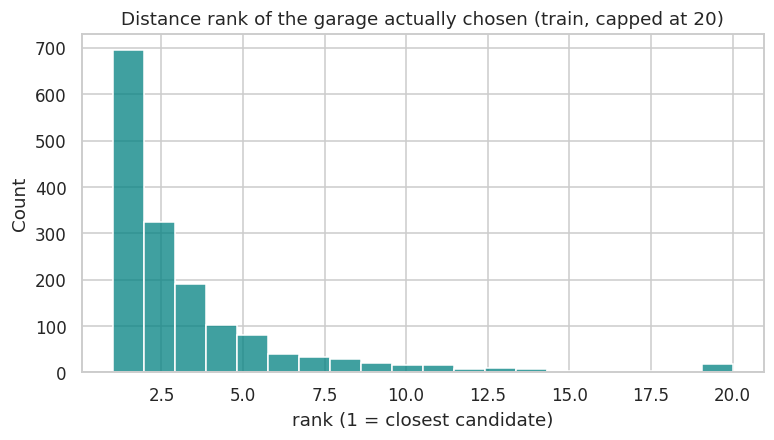

In [8]:
chosen_rank = choice_panel.loc[(choice_panel["chosen"] == 1) & (choice_panel["split"] == "train"), "dist_rank"]

print(chosen_rank.describe())
print(f"\nshare of train claims where the chosen garage is the closest candidate: {(chosen_rank == 1).mean():.1%}")
print(f"share within the 3 closest candidates: {(chosen_rank <= 3).mean():.1%}")

plt.figure(figsize=(8, 4))
sns.histplot(chosen_rank.clip(upper=20), bins=20, color="teal")
plt.title("Distance rank of the garage actually chosen (train, capped at 20)")
plt.xlabel("rank (1 = closest candidate)")
plt.show()

Strong signal: a large share of customers pick the single closest candidate garage, and the large majority land in the top few by distance. `dist_km` / `dist_rank` should be among the most important features in the choice model. It also means the "nearest garage" rule is the real baseline the model has to beat, not random guessing.

## Garage popularity feature (leakage-safe, smoothed)

A garage's general popularity for a given manufacturer - independent of any single claim's geography - is a useful prior (some garages just have a stronger reputation or more capacity). Three things to get right, because this is a target encoding and the easiest place in the whole project to leak the label:

1. **Train only.** All counts come from the train split. Test rows get the full train statistic.
2. **Leave-one-out on train rows.** For a train row, the claim's own choice is removed from its garage's count before computing the share. Without this, each positive row carries a piece of its own label inside the feature - the model latches onto it, looks great on train and CV (the leak is shared across folds), and collapses on test. I hit exactly this in a first pass, and LOO encoding is the fix.
3. **Smoothing.** With ~64 train claims per manufacturer, raw shares are noisy. The share is shrunk toward the uniform prior of 1/100 with m=20 pseudo-observations: garages with little evidence stay near the prior, garages with real history move away from it.

In [9]:
M_SMOOTH = 20
PRIOR = 1 / 100

train_mask = choice_panel["split"] == "train"

stats = (
    choice_panel[train_mask]
    .groupby(["car_manufacturer", "candidate_garage_id"])["chosen"]
    .agg(chosen_count="sum", n_claims="size")
)
choice_panel = choice_panel.merge(
    stats, left_on=["car_manufacturer", "candidate_garage_id"], right_index=True, how="left"
)
choice_panel[["chosen_count", "n_claims"]] = choice_panel[["chosen_count", "n_claims"]].fillna(0)

# test rows: full train statistic. train rows: leave-one-out (own outcome removed from the counts)
share_full = (choice_panel["chosen_count"] + M_SMOOTH * PRIOR) / (choice_panel["n_claims"] + M_SMOOTH)
share_loo = (choice_panel["chosen_count"] - choice_panel["chosen"] + M_SMOOTH * PRIOR) / (
    choice_panel["n_claims"] - 1 + M_SMOOTH
)
choice_panel["garage_manufacturer_share"] = np.where(train_mask, share_loo, share_full)
choice_panel = choice_panel.drop(columns=["chosen_count", "n_claims"])

# save the full-statistic lookup - it's part of the inference artifact (a new claim needs this feature too)
lookup = stats.reset_index()
lookup["garage_manufacturer_share"] = (lookup["chosen_count"] + M_SMOOTH * PRIOR) / (lookup["n_claims"] + M_SMOOTH)
lookup[["car_manufacturer", "candidate_garage_id", "garage_manufacturer_share"]].to_csv(
    "data/garage_share_lookup.csv", index=False
)

choice_panel.groupby("split")["garage_manufacturer_share"].describe().round(4)

,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,40000.0,0.01,0.0105,0.0021,0.0023,0.0026,0.0148,0.0697
train,160000.0,0.01,0.0106,0.0021,0.0024,0.0027,0.0150,0.0705


## City reference table (inference bundle)

At inference, a new claim may arrive without coordinates (or without city attributes at all). The serving path completes them from this reference: one row per locality with its type, SES cluster and centroid, built from the **train split only**. Saved next to the other lookups - it's part of the artifact, not an afterthought.

In [10]:
city_reference = (
    claims[claims["split"] == "train"]
    .groupby("insured_city_id")
    .agg(
        insured_city_type=("insured_city_type", "first"),
        insured_city_ses_cluster=("insured_city_ses_cluster", "first"),
        insured_lat=("insured_lat", "mean"),
        insured_lon=("insured_lon", "mean"),
    )
    .reset_index()
)
city_reference.to_csv("data/city_reference.csv", index=False)
print(f"city reference: {city_reference.shape[0]} localities saved")

city reference: 120 localities saved


## Final panel check

Confirming shapes, no unexpected nulls, and the split proportions carried over correctly from the claim-level split. The saved choice panel also keeps the claim-level severity features (vehicle, driver, damage type) - they're needed at ranking time, when the severity model scores every candidate garage of a claim.

In [11]:
choice_features = [
    "dist_km", "log_dist_km", "dist_rank", "ses_delta", "city_type_match",
    "garage_manufacturer_share", "garage_city_type", "garage_city_ses_cluster",
    "insured_city_type", "insured_city_ses_cluster", "opened_by", "car_manufacturer",
]

# claim-level columns carried along for the combined ranking step
ranking_context = [
    "vehicle_age", "vehicle_value_nis", "driver_age", "damage_type",
    "driver_age_was_imputed", "damage_cost_nis",
]

choice_model_panel = choice_panel[
    ["claim_id", "candidate_garage_id", "split", "chosen"] + choice_features + ranking_context
].copy()

print(choice_model_panel.shape)
print(choice_model_panel[choice_features].isnull().sum().sum(), "missing values in model features")
choice_model_panel.groupby("split")["chosen"].agg(["count", "sum", "mean"])

(200000, 22)
0 missing values in model features


,count,sum,mean
split,,,
test,40000,400,0.01
train,160000,1600,0.01


## Saving both panels

Both go to CSV, ready for Step 3 (model training).

In [12]:
severity_panel.to_csv("data/severity_panel.csv", index=False)
choice_model_panel.to_csv("data/choice_panel.csv", index=False)
print("saved severity_panel.csv:", severity_panel.shape)
print("saved choice_panel.csv:  ", choice_model_panel.shape)

saved severity_panel.csv: (2000, 16)
saved choice_panel.csv:   (200000, 22)


## Step 2 summary

- Split 2,000 claims 80/20 **chronologically** by `event_date` (out-of-time test) and reused it across both panels, so no claim's rows leak across train/test in the choice model. Tuning will use cross validation inside train instead of a fixed validation set. Confirmed categorical representation stays consistent across splits despite the time-based cut.
- Severity panel is a claim-level table (2,000 rows) that now includes chosen-garage features (locality type, SES, distance), so predicted cost can differ between garages - which the final ranking needs.
- Choice panel expands to 200,000 rows (2,000 claims x 100 candidates), with distance, SES gap, locality-type match, and a smoothed, train-only garage popularity prior as the key discriminating features.
- Early signal check (train only) confirms distance is highly predictive of the actual choice - so the "nearest garage" rule is the baseline to beat in modeling.

**Next (Step 3):** baselines, the two model pipelines with light Optuna tuning, metrics, the combined garage ranking, and saving the pipeline artifacts.